In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier


In [8]:
# 1. Definir las rutas de los archivos CSV preprocesados
path_train = "dfFinalMA_Train/MA_TRAIN.csv"
path_test  = "dfFinalMA_Test/MA_Test.csv"

# 2. Cargar los datasets
df_train = pd.read_csv(path_train)
df_test  = pd.read_csv(path_test)

# 3. Verificación de carga
print("==============================================")
print("        DATASETS CARGADOS CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Dimensiones de Test:  {df_test.shape[0]} filas, {df_test.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df_train.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df_train.head())

        DATASETS CARGADOS CON ÉXITO           
Dimensiones de Train: 6375 filas, 15 columnas
Dimensiones de Test:  1608 filas, 15 columnas

--- Tipos de datos en Train ---
User_ID                       object
Age                            int64
Gender                        object
User_Archetype                object
Primary_Platform              object
Daily_Screen_Time_Hours      float64
Dominant_Content_Type         object
Activity_Type                 object
Late_Night_Usage                bool
Social_Comparison_Trigger       bool
Sleep_Duration_Hours         float64
GAD_7_Score                    int64
GAD_7_Severity                object
PHQ_9_Score                    int64
PHQ_9_Severity                object
dtype: object

--- Primeras 5 filas de Train ---


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-00061085,19,MALE,PASSIVE SCROLLER,FACEBOOK,4.0,NEWS/POLITICS,PASSIVE,True,False,5.8,8,MILD,8,MILD
1,U-00088ACC,20,MALE,PASSIVE SCROLLER,TIKTOK,4.0,NEWS/POLITICS,PASSIVE,True,False,4.2,10,MODERATE,7,MILD
2,U-000A7FEC,20,MALE,AVERAGE USER,INSTAGRAM,3.6,LIFESTYLE/FASHION,ACTIVE,False,True,6.9,10,MODERATE,0,NONE-MINIMAL
3,U-00228E6E,19,MALE,PASSIVE SCROLLER,YOUTUBE,3.1,LIFESTYLE/FASHION,PASSIVE,False,False,6.2,7,MILD,9,MILD
4,U-00262C0F,18,FEMALE,AVERAGE USER,LINKEDIN,2.4,EDUCATIONAL/TECH,ACTIVE,False,False,6.4,9,MILD,1,NONE-MINIMAL


In [9]:
# 1. Filtrar únicamente Moderate y Severe
df_train = df_train[df_train['GAD_7_Severity'].isin(['MODERATE', 'SEVERE'])].copy()
df_test = df_test[df_test['GAD_7_Severity'].isin(['MODERATE', 'SEVERE'])].copy()

# 2. Definir la variable objetivo
le = LabelEncoder()

df_train['GAD_7_Severity'] = le.fit_transform(df_train['GAD_7_Severity'])
df_test['GAD_7_Severity'] = le.transform(df_test['GAD_7_Severity'])

target_col = "GAD_7_Severity"

columnas_a_dropear = [
    "User_ID",                 
    "GAD_7_Score",
    "PHQ_9_Score",
    "PHQ_9_Severity"
]

# 3. Separar X (Características) e y (Variable Objetivo) para TRAIN
X_train = df_train.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_train = df_train[target_col]

# 4. Separar X e y para TEST
X_test = df_test.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_test = df_test[target_col]

# 5. Comprobación
print("==============================================")
print("        SEPARACIÓN Y LIMPIEZA COMPLETADA      ")
print("==============================================")
print(f"Dimensiones de X_train (Predictoras): {X_train.shape}")
print(f"Dimensiones de y_train (Objetivo):    {y_train.shape}")
print(f"Dimensiones de X_test (Predictoras):  {X_test.shape}")
print(f"Dimensiones de y_test (Objetivo):     {y_test.shape}")

print("\nColumnas que usará el modelo para aprender:")
print(list(X_train.columns))

        SEPARACIÓN Y LIMPIEZA COMPLETADA      
Dimensiones de X_train (Predictoras): (2115, 10)
Dimensiones de y_train (Objetivo):    (2115,)
Dimensiones de X_test (Predictoras):  (571, 10)
Dimensiones de y_test (Objetivo):     (571,)

Columnas que usará el modelo para aprender:
['Age', 'Gender', 'User_Archetype', 'Primary_Platform', 'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type', 'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours']


In [10]:
# 1. Identificar cuáles son las columnas numéricas
# Seleccionamos solo las columnas de tipo entero y decimal
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

print(f"Se van a escalar las siguientes columnas numéricas:\n{list(columnas_numericas)}\n")

# 2. Inicializar el StandardScaler
scaler = StandardScaler()

# 3. AjustaR  y transformar 
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# ==========================================
# 5. Comprobación de que se hizo correctamente
# ==========================================
print("--- Comprobación en TRAIN ---")
print("La media de Train debería ser muy cercana a 0:")
print(X_train[columnas_numericas].mean().round(2))
print("\nLa desviación estándar de Train debería ser 1:")
print(X_train[columnas_numericas].std().round(2))

print("\n--- Primeras filas de X_train escalado ---")
display(X_train.head()) 

Se van a escalar las siguientes columnas numéricas:
['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours']

--- Comprobación en TRAIN ---
La media de Train debería ser muy cercana a 0:
Age                       -0.0
Daily_Screen_Time_Hours    0.0
Sleep_Duration_Hours      -0.0
dtype: float64

La desviación estándar de Train debería ser 1:
Age                        1.0
Daily_Screen_Time_Hours    1.0
Sleep_Duration_Hours       1.0
dtype: float64

--- Primeras filas de X_train escalado ---


,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours
1,0.806220,MALE,PASSIVE SCROLLER,TIKTOK,-1.239567,NEWS/POLITICS,PASSIVE,True,False,-0.860765
2,0.806220,MALE,AVERAGE USER,INSTAGRAM,-1.496418,LIFESTYLE/FASHION,ACTIVE,False,True,1.553241
9,-0.958952,MALE,HYPER-CONNECTED,SNAPCHAT,0.301542,LIFESTYLE/FASHION,ACTIVE,True,False,-1.307804
13,-0.958952,FEMALE,PASSIVE SCROLLER,TWITTER/X,-0.340586,SELF-HELP/MOTIVATION,PASSIVE,True,False,1.553241
15,0.806220,MALE,HYPER-CONNECTED,INSTAGRAM,0.494181,SELF-HELP/MOTIVATION,ACTIVE,False,True,-0.950173


In [11]:
# 1. Definir qué columnas son categóricas
columnas_categoricas = ['Gender', 'User_Archetype', 'Primary_Platform', 'Dominant_Content_Type','Activity_Type']

# 2. Aplicar One-Hot Encoding a Train y Test
X_train_codificado = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test_codificado = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# 3. ALINEAR Train y Test
X_train_codificado, X_test_codificado = X_train_codificado.align(X_test_codificado, join='left', axis=1, fill_value=0)

print(f"Columnas finales para entrenar: {X_train_codificado.shape[1]}")

Columnas finales para entrenar: 21


In [14]:
# 1. Definir el modelo base
logreg_model = LogisticRegression(
    random_state=46,
    max_iter=5000,
)

# 2. Definir la parrilla de hiperparámetros que quieres probar
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

# 3. Configurar el GridSearch con Validación Cruzada (5 folds)
grid_search = GridSearchCV(
    estimator=logreg_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("--- Iniciando búsqueda de hiperparámetros (Grid Search) ---")

grid_search.fit(X_train_codificado, y_train)

# 4. Ver los mejores resultados
print("\n==============================================")
print("       MEJORES HIPERPARÁMETROS ENCONTRADOS    ")
print("==============================================")
print(grid_search.best_params_)
print(f"Mejor F1 Weighted en Validación Cruzada: {grid_search.best_score_:.4f}")

--- Iniciando búsqueda de hiperparámetros (Grid Search) ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits

       MEJORES HIPERPARÁMETROS ENCONTRADOS    
{'C': 10}
Mejor F1 Weighted en Validación Cruzada: 0.7541


       MÉTRICAS EN TEST (Regresión Logística)  
Accuracy  : 77.76%
Precision : 73.55%
Recall    : 77.76%
F1 Score  : 71.84%

              precision    recall  f1-score   support

    MODERATE       0.79      0.97      0.87       441
      SEVERE       0.55      0.12      0.20       130

    accuracy                           0.78       571
   macro avg       0.67      0.55      0.54       571
weighted avg       0.74      0.78      0.72       571



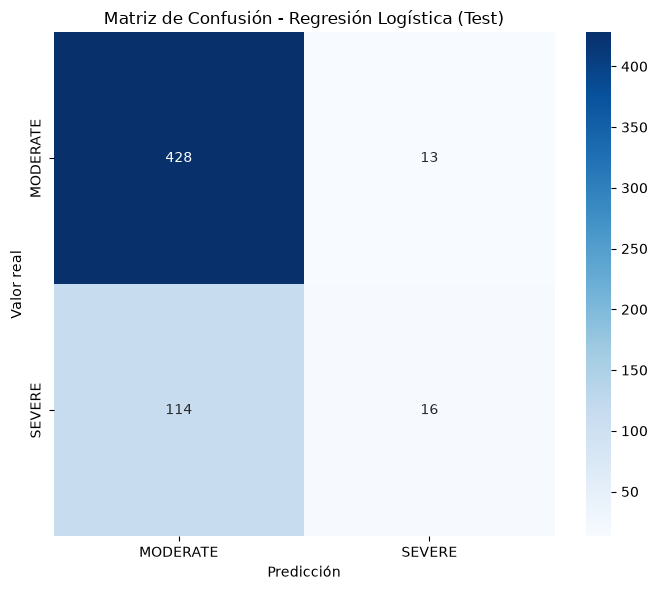

In [15]:
# 1. Tomar el mejor modelo encontrado por el GridSearch
best_model = grid_search.best_estimator_

# 2. Predecir sobre el set de TEST (nunca visto durante el entrenamiento/CV)
y_pred = best_model.predict(X_test_codificado)

# 3. Calcular métricas sobre el test set
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("==============================================")
print("       MÉTRICAS EN TEST (Regresión Logística)  ")
print("==============================================")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 4. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Regresión Logística (Test)')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# 2. Definir la parrilla de hiperparámetros
param_grid = {
    'n_estimators': [50,100, 300, 500,1000],
    'max_depth': range(1,10),
    'learning_rate': [0.01, 0.05, 0.1,0.2],
}

# 3. Configurar GridSearch con Validación Cruzada (5 folds)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("--- Iniciando búsqueda de hiperparámetros (Grid Search) ---")

grid_search.fit(X_train_codificado, y_train, sample_weight=sample_weights)

# 4. Ver los mejores resultados
print("\n==============================================")
print("       MEJORES HIPERPARÁMETROS ENCONTRADOS    ")
print("==============================================")
print(grid_search.best_params_)
print(f"Mejor F1 Weighted en Validación Cruzada: {grid_search.best_score_:.4f}")

--- Iniciando búsqueda de hiperparámetros (Grid Search) ---
Fitting 5 folds for each of 180 candidates, totalling 900 fits

       MEJORES HIPERPARÁMETROS ENCONTRADOS    
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Mejor F1 Weighted en Validación Cruzada: 0.6539


       MÉTRICAS EN TEST (Regresión Logística)  
Accuracy  : 65.67%
Precision : 75.65%
Recall    : 65.67%
F1 Score  : 68.35%

              precision    recall  f1-score   support

    MODERATE       0.87      0.65      0.75       441
      SEVERE       0.36      0.68      0.47       130

    accuracy                           0.66       571
   macro avg       0.62      0.66      0.61       571
weighted avg       0.76      0.66      0.68       571



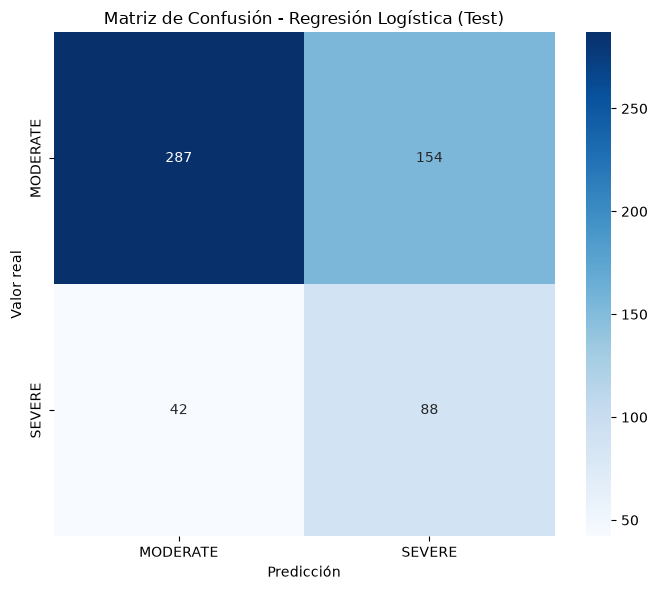

In [22]:
# 1. Tomar el mejor modelo encontrado por el GridSearch
best_model = grid_search.best_estimator_

# 2. Predecir sobre el set de TEST (nunca visto durante el entrenamiento/CV)
y_pred = best_model.predict(X_test_codificado)

# 3. Calcular métricas sobre el test set
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("==============================================")
print("       MÉTRICAS EN TEST (Regresión Logística)  ")
print("==============================================")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 4. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Regresión Logística (Test)')
plt.tight_layout()
plt.show()